# Climate-Aware Aircraft Route Optimization Using a Genetic Algorithm

**Student:** Mariah Howarth  
**Course:** Topics in Computational Modelling: From Information Theory to Evolutionary Models  
**Project Type:** Evolutionary Computing / Genetic Algorithm

This project uses a genetic algorithm to optimize aircraft flight paths in a simplified simulated airspace. The goal is to reduce estimated aviation climate impact by balancing route distance, wind effects, contrail-risk exposure, route smoothness, and restricted airspace penalties.

## Abstract

Aircraft route planning involves several competing objectives. A direct route may minimize distance and fuel use, but it may also pass through atmospheric regions where persistent contrails are more likely to form. Because contrails can contribute to aviation climate impact, a more climate-aware route may sometimes require a controlled detour.

This project implements a genetic algorithm to search for optimized aircraft routes in a simulated two-dimensional airspace. Each candidate solution is represented as a sequence of intermediate waypoints between an origin and destination. The algorithm evaluates each route using a cost function that includes distance, contrail-risk exposure, wind effects, route smoothness, and restricted airspace penalties.

The optimized route is compared against a direct-route baseline and a random-search baseline. Additional experiments test how mutation rate and population size affect the final route cost.

## 1. Problem Background

Aviation climate impact is affected by both fuel-related emissions and non-CO₂ effects such as contrails. A direct flight path is usually efficient in terms of distance, but it may cross atmospheric regions where persistent contrails are more likely to occur. Avoiding these regions can reduce contrail exposure, but it may also increase route distance and therefore fuel use.

This creates an optimization problem: the best route is not necessarily the shortest route. Instead, a route should balance distance, fuel-use proxy, wind conditions, and contrail-risk exposure.

Evolutionary computing is suitable for this problem because there are many possible route combinations. A genetic algorithm can explore different waypoint sequences and evolve better routes over multiple generations.

## 2. Problem Definition

The goal of this project is to find a route from a fixed origin to a fixed destination that minimizes total environmental route cost.

The route cost includes:

- distance, used as a simplified proxy for fuel use and CO₂ emissions
- contrail-risk exposure
- wind effects, where tailwinds reduce cost and headwinds increase cost
- smoothness penalties to discourage unrealistic zigzag routes
- restricted-zone penalties to avoid invalid airspace

The optimization objective is:


minimize total route cost


A lower route cost means the route is considered better under the simplified model.

## 3. Model Assumptions

This project uses a simplified model rather than real aviation and meteorological data. The main assumptions are:

1. The airspace is represented as a two-dimensional grid.
2. The aircraft travels from the left side of the grid to the right side.
3. Route distance is used as a proxy for fuel burn and CO₂ emissions.
4. Contrail risk is represented by synthetic risk regions on the grid.
5. Wind is represented by simplified tailwind and headwind corridors.
6. Restricted airspace is represented by a fixed penalty zone.
7. The aircraft route is represented by a sequence of intermediate waypoints.
8. Lower total cost indicates a more climate-aware route.

These simplifications make the problem manageable while still demonstrating the core idea of evolutionary route optimization.


A lower route cost means the route is considered better under the simplified model.

## 4. Simulated Airspace Setup

The following code creates the simulated environment. The grid contains contrail-risk regions, wind-effect zones, and restricted airspace. The origin and destination are fixed points on opposite sides of the grid.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# grid dimensions for simulated airspace
GRID_HEIGHT = 30
GRID_WIDTH = 50

# origin and destination represented as grid coords (row, column)
origin = (GRID_HEIGHT // 2, 0)
destination = (GRID_HEIGHT // 2, GRID_WIDTH - 1)

# creates coordinate grids
y, x = np.mgrid[0:GRID_HEIGHT, 0:GRID_WIDTH]

# contrail risk map:
# higher values represent atmospheric regions where persistent contrails are more likely
contrail_risk = (
    0.9 * np.exp(-(((x - 18) ** 2) / (2 * 6 ** 2) + ((y - 8) ** 2) / (2 * 5 ** 2))) +
    1.0 * np.exp(-(((x - 35) ** 2) / (2 * 7 ** 2) + ((y - 22) ** 2) / (2 * 4 ** 2)))
)

# normalize contrail risk (so values are between 0 and 1)
contrail_risk = (contrail_risk - contrail_risk.min()) / (contrail_risk.max() - contrail_risk.min())

# wind map:
# positive values represent helpful tailwinds.
# negative values represent headwinds.
tailwind_corridor = np.exp(-((y - 12) ** 2) / (2 * 3 ** 2))
headwind_corridor = np.exp(-((y - 24) ** 2) / (2 * 4 ** 2))

wind_effect = 0.7 * tailwind_corridor - 0.4 * headwind_corridor
wind_effect = np.clip(wind_effect, -0.5, 0.7)

# restricted airspace:
# routes crossing this zone receive a large penalty
restricted_zone = np.zeros((GRID_HEIGHT, GRID_WIDTH))
restricted_zone[16:23, 22:29] = 1

print("Simulated airspace created")
print("Grid size:", GRID_HEIGHT, "x", GRID_WIDTH)
print("Origin:", origin)
print("Destination:", destination)

Simulated airspace created
Grid size: 30 x 50
Origin: (15, 0)
Destination: (15, 49)


## 5. Route Evaluation and Cost Function

Each route is evaluated using a cost function. The cost function combines multiple factors that influence route quality.

The total route cost is calculated as:

$$
\text{total cost} =
\text{distance}
+ 20(\text{contrail exposure})
- 5(\text{wind benefit})
+ 2(\text{smoothness penalty})
+ 300(\text{restricted crossings})
$$

Distance represents a simplified fuel-use and CO₂ proxy. Contrail exposure penalizes routes that pass through high-risk atmospheric regions. Wind benefit reduces cost when the route passes through favorable tailwind areas. Smoothness discourages unrealistic sharp turns. Restricted crossings receive a large penalty because those routes are considered invalid or undesirable.

The genetic algorithm minimizes this total route cost.

In [3]:
def make_direct_route(origin, destination, n_points=GRID_WIDTH):
    
    # create a straight route from origin to destination
    
    # each route point is represented as (row, column)
    
    y_values = np.linspace(origin[0], destination[0], n_points)
    x_values = np.linspace(origin[1], destination[1], n_points)

    route = [(int(round(y)), int(round(x))) for y, x in zip(y_values, x_values)]

    return route


def route_distance(route):
    
    # calculate the total distance along the route
    
    total = 0

    for i in range(1, len(route)):
        y1, x1 = route[i - 1]
        y2, x2 = route[i]

        total += np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)

    return total


def route_contrail_exposure(route):
    
    # sum the contrail risk over all grid cells visited by the route
    
    return sum(contrail_risk[y, x] for y, x in route)


def route_wind_benefit(route):
    
    # sum the wind effect over the route

    # positive values are beneficial tailwinds, negative values are harmful headwinds
    
    return sum(wind_effect[y, x] for y, x in route)


def route_restricted_crossings(route):
    
    # count how many route points cross restricted airspace
    
    return sum(restricted_zone[y, x] for y, x in route)


def route_smoothness_penalty(route):
    
    # penalize sharp vertical changes between consecutive waypoints

    # this discourages unrealistic zigzag routes
    
    penalty = 0

    for i in range(2, len(route)):
        previous_slope = route[i - 1][0] - route[i - 2][0]
        current_slope = route[i][0] - route[i - 1][0]

        penalty += abs(current_slope - previous_slope)

    return penalty


def route_cost(route):
    """
    calculate the total cost of a route

    lower cost is better

    The cost function combines:
    - distance / fuel cost
    - contrail-risk exposure
    - wind effect
    - route smoothness
    - restricted-zone penalty
    """

    distance = route_distance(route)
    contrail = route_contrail_exposure(route)
    wind = route_wind_benefit(route)
    restricted = route_restricted_crossings(route)
    smoothness = route_smoothness_penalty(route)

    total_cost = (
        distance
        + 20 * contrail
        - 5 * wind
        + 2 * smoothness
        + 300 * restricted
    )

    return {
        "total_cost": total_cost,
        "distance": distance,
        "contrail_exposure": contrail,
        "wind_benefit": wind,
        "smoothness_penalty": smoothness,
        "restricted_crossings": restricted
    }

## 6. Direct Route Baseline

The direct route provides a simple baseline for comparison. It travels in a straight line from the origin to the destination. This route is usually shortest in distance, but it may pass through high contrail-risk areas.

In [4]:
direct_route = make_direct_route(origin, destination)
direct_metrics = route_cost(direct_route)

print("Direct route metrics:")

for key, value in direct_metrics.items():
    print(f"{key}: {value:.2f}")

Direct route metrics:
total_cost: 126.70
distance: 49.00
contrail_exposure: 8.79
wind_benefit: 19.64
smoothness_penalty: 0.00
restricted_crossings: 0.00


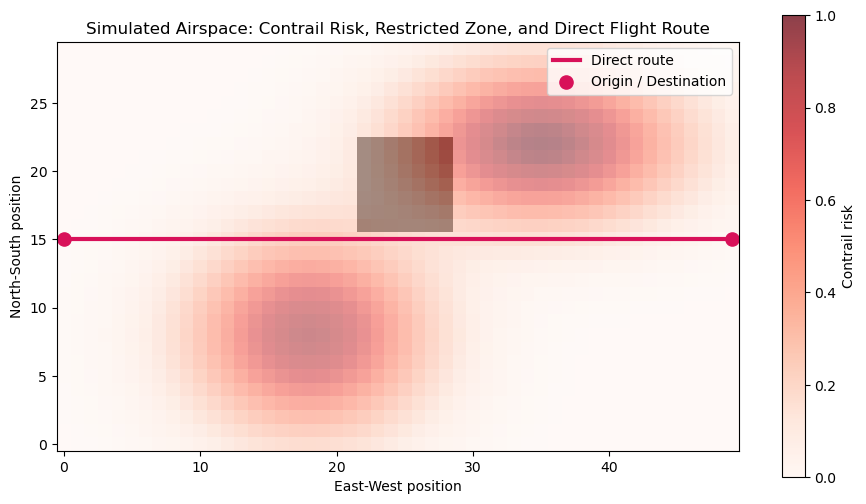

In [5]:
plt.figure(figsize=(11, 6))

# show contrail-risk background
contrail_plot = plt.imshow(
    contrail_risk,
    origin="lower",
    cmap="Reds",
    alpha=0.75
)

# overlay restricted airspace
plt.imshow(
    restricted_zone,
    origin="lower",
    cmap="Greys",
    alpha=0.35
)

# extract route coordinates for plotting
route_y = [point[0] for point in direct_route]
route_x = [point[1] for point in direct_route]

# plot route
plt.plot(route_x, route_y, linewidth=3, color="#D81159", label="Direct route")

plt.scatter(
    [origin[1], destination[1]],
    [origin[0], destination[0]],
    s=90,
    color="#D81159",
    label="Origin / Destination"
)

plt.title("Simulated Airspace: Contrail Risk, Restricted Zone, and Direct Flight Route")
plt.xlabel("East-West position")
plt.ylabel("North-South position")
plt.legend()
plt.colorbar(contrail_plot, label="Contrail risk")
plt.show()

The direct route is useful as a baseline because it represents the simplest possible route. However, the shortest path is not always the best environmental option if it crosses high contrail-risk regions.

In [6]:
# adding an extra contrail-risk region near the direct route
# creating a test case where the shortest route is not the lowest-impact route

central_contrail_risk = 1.4 * np.exp(
    -(
        ((x - 25) ** 2) / (2 * 6 ** 2)
        + ((y - 15) ** 2) / (2 * 3 ** 2)
    )
)

contrail_risk = contrail_risk + central_contrail_risk

# normalize again 
contrail_risk = (contrail_risk - contrail_risk.min()) / (contrail_risk.max() - contrail_risk.min())

# recalculate direct route after updating the environment
direct_route = make_direct_route(origin, destination)
direct_metrics = route_cost(direct_route)

print("Updated direct route metrics:")

for key, value in direct_metrics.items():
    print(f"{key}: {value:.2f}")

Updated direct route metrics:
total_cost: 312.87
distance: 49.00
contrail_exposure: 18.10
wind_benefit: 19.64
smoothness_penalty: 0.00
restricted_crossings: 0.00


## 7. Genetic Algorithm Representation

In this project, each individual represents one possible aircraft route. The origin and destination are fixed, while the genetic algorithm controls the vertical positions of intermediate waypoints.

For example, an individual may look like:
\
[13, 7, 5, 4, 8, 12, 14, 15]


Each number represents the row position of a waypoint at a fixed column in the grid. This representation allows the genetic algorithm to evolve different route shapes while still moving from the origin to the destination.

In [7]:
# Genetic Algorithm Route Representation

# x positions are fixed across the airspace, GA chooses the y positions

NUM_WAYPOINTS = 8

# avoid unrealistic routes along the very top or bottom edge of the map

MIN_ROUTE_ROW = 3
MAX_ROUTE_ROW = GRID_HEIGHT - 4

# fixed x positions
waypoint_columns = np.linspace(1, GRID_WIDTH - 2, NUM_WAYPOINTS, dtype=int)


def create_random_individual():
    
    # the individual only stores the y-positions of intermediate waypoints, the origin and destination are fixed
    
    return np.random.randint(
        MIN_ROUTE_ROW,
        MAX_ROUTE_ROW + 1,
        size=NUM_WAYPOINTS
    )


def individual_to_route(individual):
    
    # convert a GA individual into a full route across the grid

    control_x = np.array(
        [origin[1]] + list(waypoint_columns) + [destination[1]]
    )

    control_y = np.array(
        [origin[0]] + list(individual) + [destination[0]]
    )

    route_x = np.arange(GRID_WIDTH)
    route_y = np.interp(route_x, control_x, control_y)

    route = []

    for col in route_x:
        row = int(round(route_y[col]))
        row = int(np.clip(row, 0, GRID_HEIGHT - 1))
        route.append((row, int(col)))

    return route


# test test test
test_individual = create_random_individual()
test_route = individual_to_route(test_individual)
test_metrics = route_cost(test_route)

print("Example individual:")
print(test_individual)

print("\nExample route metrics:")

for key, value in test_metrics.items():
    print(f"{key}: {value:.2f}")

Example individual:
[ 9 22 17 13 10 23  9 21]

Example route metrics:
total_cost: 443.80
distance: 95.97
contrail_exposure: 15.46
wind_benefit: 12.27
smoothness_penalty: 50.00
restricted_crossings: 0.00


## 8. Genetic Algorithm Methodology

The genetic algorithm uses the following evolutionary components:

- **Initial population:** A set of randomly generated routes.
- **Fitness evaluation:** Each route is evaluated using the route-cost function.
- **Selection:** Tournament selection chooses stronger routes as parents.
- **Crossover:** Parent routes exchange waypoint segments to create children.
- **Mutation:** Individual waypoint positions are randomly adjusted.
- **Elitism:** The best individuals are preserved between generations.

Because this is a minimization problem, individuals with lower route cost are considered better.

In [8]:
# Genetic Algorithm Parameters

POPULATION_SIZE = 100
GENERATIONS = 200
TOURNAMENT_SIZE = 4
CROSSOVER_RATE = 0.80
MUTATION_RATE = 0.12
MUTATION_STRENGTH = 4
ELITE_SIZE = 2


def create_initial_population(pop_size):
    
    # create the initial population

    # one individual is initialized as a direct-route style solution, the rest are random routes
    
    population = [create_random_individual() for _ in range(pop_size)]

    # add a direct-route baseline to the initial population
    population[0] = np.full(NUM_WAYPOINTS, origin[0])

    return population


def evaluate_individual(individual):
    # evaluate one individual

    route = individual_to_route(individual)
    metrics = route_cost(route)

    return metrics["total_cost"]


def tournament_selection(population, costs, tournament_size=TOURNAMENT_SIZE):
    
    # a few individuals are chosen randomly, the one with the lowest route cost wins.
    
    candidate_indices = np.random.choice(
        len(population),
        size=tournament_size,
        replace=False
    )

    best_index = candidate_indices[np.argmin(costs[candidate_indices])]

    return population[best_index].copy()


def crossover(parent1, parent2):
    
    # perform one-point crossover between two parent routes.
    
    if np.random.rand() > CROSSOVER_RATE:
        return parent1.copy(), parent2.copy()

    crossover_point = np.random.randint(1, len(parent1))

    child1 = np.concatenate(
        [parent1[:crossover_point], parent2[crossover_point:]]
    )

    child2 = np.concatenate(
        [parent2[:crossover_point], parent1[crossover_point:]]
    )

    return child1, child2


def mutate(individual):
    
    # mutate an individual by randomly shifting waypoint row positions
    
    child = individual.copy()

    for i in range(len(child)):
        if np.random.rand() < MUTATION_RATE:
            change = np.random.randint(
                -MUTATION_STRENGTH,
                MUTATION_STRENGTH + 1
            )

            child[i] = np.clip(
                child[i] + change,
                MIN_ROUTE_ROW,
                MAX_ROUTE_ROW
            )

    return child

## 9. Genetic Algorithm Implementation

The genetic algorithm is run over multiple generations. In each generation, the population is evaluated, the best routes are selected, and new routes are created through crossover and mutation. The best route found across all generations is stored for final comparison.

In [9]:
def run_genetic_algorithm(
    pop_size=POPULATION_SIZE,
    generations=GENERATIONS
):
    
    # run the genetic algorithm
    
    """
    return
    - best individual found
    - best route cost
    - history of best and average costs
    """

    population = create_initial_population(pop_size)

    best_individual = None
    best_cost = float("inf")

    history = {
        "generation": [],
        "best_cost": [],
        "average_cost": []
    }

    for generation in range(generations):
        costs = np.array(
            [evaluate_individual(individual) for individual in population]
        )

        generation_best_index = int(np.argmin(costs))
        generation_best_cost = float(costs[generation_best_index])

        if generation_best_cost < best_cost:
            best_cost = generation_best_cost
            best_individual = population[generation_best_index].copy()

        history["generation"].append(generation)
        history["best_cost"].append(best_cost)
        history["average_cost"].append(float(np.mean(costs)))

        # stops a new population after final evaluation
        if generation == generations - 1:
            break

        # keeps the best individuals unchanged
        sorted_indices = np.argsort(costs)

        new_population = [
            population[i].copy()
            for i in sorted_indices[:ELITE_SIZE]
        ]

        # fills the rest of the next generation
        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, costs)
            parent2 = tournament_selection(population, costs)

            child1, child2 = crossover(parent1, parent2)

            child1 = mutate(child1)
            child2 = mutate(child2)

            new_population.append(child1)

            if len(new_population) < pop_size:
                new_population.append(child2)

        population = new_population

    return best_individual, best_cost, history


best_individual, best_cost, history = run_genetic_algorithm()

best_route = individual_to_route(best_individual)
best_metrics = route_cost(best_route)

print("Best individual found:")
print(best_individual)

print("\nBest GA route metrics:")

for key, value in best_metrics.items():
    print(f"{key}: {value:.2f}")
    

Best individual found:
[15 10  3  3  3 10 11 11]

Best GA route metrics:
total_cost: 122.83
distance: 60.41
contrail_exposure: 6.09
wind_benefit: 16.69
smoothness_penalty: 12.00
restricted_crossings: 0.00


In [10]:
import pandas as pd

direct_metrics = route_cost(direct_route)
ga_metrics = route_cost(best_route)

comparison = pd.DataFrame(
    [
        {
            "Route": "Direct route",
            "Total cost": direct_metrics["total_cost"],
            "Distance": direct_metrics["distance"],
            "Contrail exposure": direct_metrics["contrail_exposure"],
            "Wind benefit": direct_metrics["wind_benefit"],
            "Smoothness penalty": direct_metrics["smoothness_penalty"],
            "Restricted crossings": direct_metrics["restricted_crossings"]
        },
        {
            "Route": "GA optimized route",
            "Total cost": ga_metrics["total_cost"],
            "Distance": ga_metrics["distance"],
            "Contrail exposure": ga_metrics["contrail_exposure"],
            "Wind benefit": ga_metrics["wind_benefit"],
            "Smoothness penalty": ga_metrics["smoothness_penalty"],
            "Restricted crossings": ga_metrics["restricted_crossings"]
        }
    ]
)

comparison

,Route,Total cost,Distance,Contrail exposure,Wind benefit,Smoothness penalty,Restricted crossings
0,Direct route,312.865253,49.000000,18.102608,19.637383,0,0.0
1,GA optimized route,122.826850,60.407377,6.093030,16.688224,12,0.0


## 10. Results

The following results show how the genetic algorithm improved route quality over time and how the optimized route compares with the direct route.

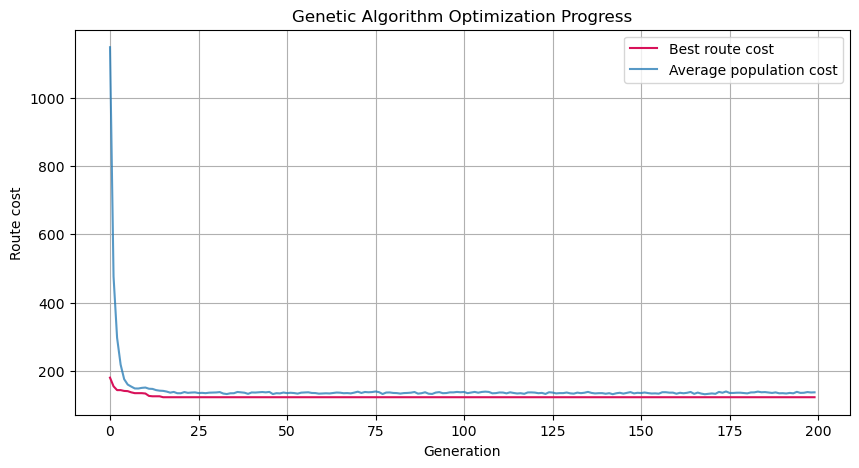

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["generation"],
    history["best_cost"],
    label="Best route cost",
    color="#D81159",
)

plt.plot(
    history["generation"],
    history["average_cost"],
    label="Average population cost",
    alpha=0.75
)

plt.title("Genetic Algorithm Optimization Progress")
plt.xlabel("Generation")
plt.ylabel("Route cost")
plt.legend()
plt.grid(True)
plt.show()

The optimization-progress plot shows whether the genetic algorithm improved over generations. A decreasing best-cost curve indicates that the algorithm successfully found better routes as evolution progressed.

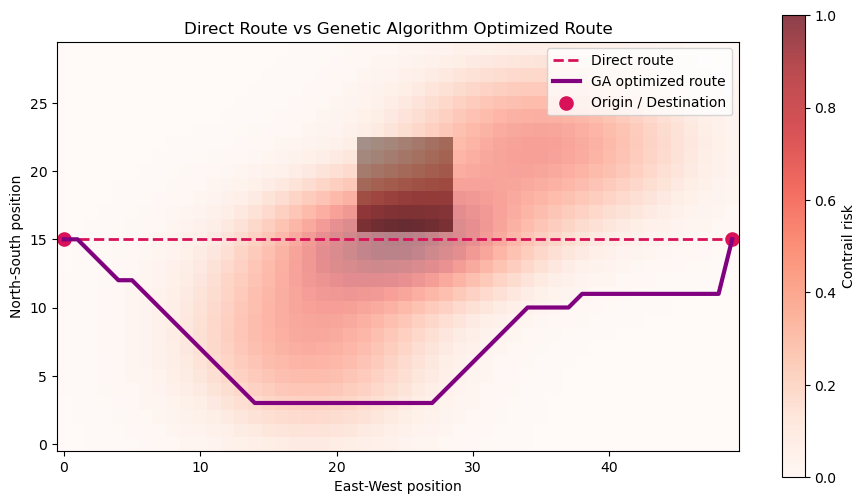

In [12]:
plt.figure(figsize=(11, 6))

# show contrail risk background
contrail_plot = plt.imshow(
    contrail_risk,
    origin="lower",
    cmap="Reds",
    alpha=0.75
)

# overlay restricted airspace
plt.imshow(
    restricted_zone,
    origin="lower",
    cmap="Greys",
    alpha=0.35
)

# direct route coordinates
direct_y = [point[0] for point in direct_route]
direct_x = [point[1] for point in direct_route]

# GA route coordinates
ga_y = [point[0] for point in best_route]
ga_x = [point[1] for point in best_route]

plt.plot(
    direct_x,
    direct_y,
    linewidth=2,
    linestyle="--",
    color="#D81159",
    label="Direct route"
)

plt.plot(
    ga_x,
    ga_y,
    linewidth=3,
    color="purple",
    label="GA optimized route"
)

plt.scatter(
    [origin[1], destination[1]],
    [origin[0], destination[0]],
    s=90,
    color="#D81159",
    label="Origin / Destination"
)

plt.title("Direct Route vs Genetic Algorithm Optimized Route")
plt.xlabel("East-West position")
plt.ylabel("North-South position")
plt.legend()
plt.colorbar(contrail_plot, label="Contrail risk")
plt.show()

The optimized route avoids the highest contrail-risk region while still maintaining a reasonable path from origin to destination. This shows that the genetic algorithm is not simply finding the shortest path, but instead balancing route distance against environmental-risk factors.

## Experimental Evaluation

To evaluate the genetic algorithm, I compare the optimized route against two baselines:

1. A direct route from the origin to the destination.
2. A random-search baseline that generates many random routes but does not use evolutionary operators.

I also test how different mutation rates and population sizes affect the final route cost.

In [13]:
def random_search_baseline(n_candidates=20000):
    """
    this generates many random routes and keeps the best one
    it does not use selection, crossover, mutation, or generations

    the purpose is to test whether the genetic algorithm performs better
    than simple random guessing
    """

    best_random_individual = None
    best_random_cost = float("inf")

    for _ in range(n_candidates):
        individual = create_random_individual()
        cost = evaluate_individual(individual)

        if cost < best_random_cost:
            best_random_cost = cost
            best_random_individual = individual.copy()

    best_random_route = individual_to_route(best_random_individual)
    best_random_metrics = route_cost(best_random_route)

    return best_random_individual, best_random_route, best_random_metrics


random_individual, random_route, random_metrics = random_search_baseline()

print("Best random-search individual:")
print(random_individual)

print("\nBest random-search route metrics:")

for key, value in random_metrics.items():
    print(f"{key}: {value:.2f}")

Best random-search individual:
[12 12  4  3  4  7 12 16]

Best random-search route metrics:
total_cost: 172.91
distance: 61.10
contrail_exposure: 6.45
wind_benefit: 15.46
smoothness_penalty: 30.00
restricted_crossings: 0.00


## 11. Baseline Comparison

To evaluate the genetic algorithm, the optimized route is compared against two baselines:

1. A direct route from origin to destination.
2. A random-search route generated without evolutionary operators.

The random-search baseline helps test whether the genetic algorithm performs better than simply generating many random routes.

In [14]:
direct_metrics = route_cost(direct_route)
ga_metrics = route_cost(best_route)

full_comparison = pd.DataFrame(
    [
        {
            "Route": "Direct route",
            "Total cost": direct_metrics["total_cost"],
            "Distance": direct_metrics["distance"],
            "Contrail exposure": direct_metrics["contrail_exposure"],
            "Wind benefit": direct_metrics["wind_benefit"],
            "Smoothness penalty": direct_metrics["smoothness_penalty"],
            "Restricted crossings": direct_metrics["restricted_crossings"]
        },
        {
            "Route": "Random search route",
            "Total cost": random_metrics["total_cost"],
            "Distance": random_metrics["distance"],
            "Contrail exposure": random_metrics["contrail_exposure"],
            "Wind benefit": random_metrics["wind_benefit"],
            "Smoothness penalty": random_metrics["smoothness_penalty"],
            "Restricted crossings": random_metrics["restricted_crossings"]
        },
        {
            "Route": "GA optimized route",
            "Total cost": ga_metrics["total_cost"],
            "Distance": ga_metrics["distance"],
            "Contrail exposure": ga_metrics["contrail_exposure"],
            "Wind benefit": ga_metrics["wind_benefit"],
            "Smoothness penalty": ga_metrics["smoothness_penalty"],
            "Restricted crossings": ga_metrics["restricted_crossings"]
        }
    ]
)

full_comparison

,Route,Total cost,Distance,Contrail exposure,Wind benefit,Smoothness penalty,Restricted crossings
0,Direct route,312.865253,49.000000,18.102608,19.637383,0,0.0
1,Random search route,172.910272,61.096830,6.454864,15.456767,30,0.0
2,GA optimized route,122.826850,60.407377,6.093030,16.688224,12,0.0


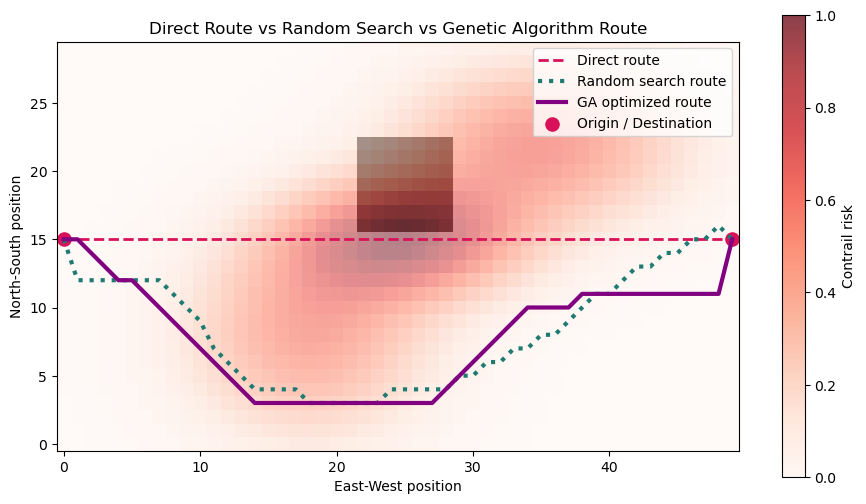

In [15]:
plt.figure(figsize=(11, 6))

contrail_plot = plt.imshow(
    contrail_risk,
    origin="lower",
    cmap="Reds",
    alpha=0.75
)

plt.imshow(
    restricted_zone,
    origin="lower",
    cmap="Greys",
    alpha=0.35
)

# direct route coordinates
direct_y = [point[0] for point in direct_route]
direct_x = [point[1] for point in direct_route]

# random route coordinates
random_y = [point[0] for point in random_route]
random_x = [point[1] for point in random_route]

# GA route coordinates
ga_y = [point[0] for point in best_route]
ga_x = [point[1] for point in best_route]

plt.plot(
    direct_x,
    direct_y,
    linewidth=2,
    linestyle="--",
    color="#D81159",
    label="Direct route"
)

plt.plot(
    random_x,
    random_y,
    linewidth=3,
    linestyle=":",
    color="#1F7A72",
    label="Random search route"
)

plt.plot(
    ga_x,
    ga_y,
    linewidth=3,
    color="purple",
    label="GA optimized route"
)

plt.scatter(
    [origin[1], destination[1]],
    [origin[0], destination[0]],
    s=90,
    color="#D81159",
    label="Origin / Destination"
)

plt.title("Direct Route vs Random Search vs Genetic Algorithm Route")
plt.xlabel("East-West position")
plt.ylabel("North-South position")
plt.legend()
plt.colorbar(contrail_plot, label="Contrail risk")
plt.show()

The comparison shows whether the genetic algorithm provides a meaningful improvement over both the direct route and random search. The direct route is useful as a distance-based baseline, while the random-search route is useful as a non-evolutionary optimization baseline.

## Results Interpretation

The optimized genetic algorithm route differs from the direct route because the direct path crosses a high contrail-risk region. Although the direct route is shorter, it has higher exposure to atmospheric conditions where persistent contrails may form. The genetic algorithm instead finds a route that detours around the highest-risk area.

This result demonstrates the environmental tradeoff in the problem. A longer route may increase fuel use and CO₂ emissions, but it can still be preferable if the reduction in contrail-related climate impact is large enough. The cost function accounts for this tradeoff by combining route distance, contrail exposure, wind effects, route smoothness, and restricted airspace penalties.

The random-search baseline provides a comparison against non-evolutionary optimization. Unlike random search, the genetic algorithm uses selection, crossover, mutation, and elitism to improve candidate routes over generations.

In [16]:
summary_table = full_comparison.copy()

direct_total_cost = direct_metrics["total_cost"]

summary_table["Percent improvement vs direct route"] = (
    (direct_total_cost - summary_table["Total cost"]) / direct_total_cost
) * 100

summary_table

,Route,Total cost,Distance,Contrail exposure,Wind benefit,Smoothness penalty,Restricted crossings,Percent improvement vs direct route
0,Direct route,312.865253,49.000000,18.102608,19.637383,0,0.0,0.000000
1,Random search route,172.910272,61.096830,6.454864,15.456767,30,0.0,44.733309
2,GA optimized route,122.826850,60.407377,6.093030,16.688224,12,0.0,60.741294


## Preliminary Conclusion

The genetic algorithm successfully found a flight path with a lower total environmental cost than the direct route. The optimized path avoids the highest contrail-risk region while still maintaining a reasonable route distance. This supports the idea that evolutionary computing can be used to search for climate-aware aircraft trajectories in a simplified airspace model.

The model is simplified and does not use real meteorological data, real aircraft fuel-burn equations, or actual air traffic control constraints. However, it demonstrates the main optimization concept: flight paths can be evaluated using multiple competing environmental factors, and a genetic algorithm can evolve improved solutions over time.

## Parameter Sensitivity Experiments

Because genetic algorithms are stochastic, their performance can change depending on parameters such as mutation rate and population size. In this section, I test different settings to evaluate how these parameters affect the final route cost.

In [17]:
def run_ga_with_settings(
    pop_size=100,
    generations=150,
    mutation_rate=0.12,
    seed=None
):
    
    # run the genetic algorithm with a specific mutation rate and population size

    global MUTATION_RATE

    original_mutation_rate = MUTATION_RATE

    try:
        MUTATION_RATE = mutation_rate

        if seed is not None:
            np.random.seed(seed)

        best_individual, best_cost, history = run_genetic_algorithm(
            pop_size=pop_size,
            generations=generations
        )

    finally:
        MUTATION_RATE = original_mutation_rate

    return best_individual, best_cost, history


def mutation_rate_experiment(
    mutation_rates=[0.01, 0.05, 0.12, 0.20, 0.30],
    repeats=5,
    pop_size=100,
    generations=150
):
    
    # test several mutation rates.

    # each mutation rate is tested multiple times 
    

    results = []

    for mutation_rate in mutation_rates:
        final_costs = []

        for repeat in range(repeats):
            seed = 1000 + repeat

            best_individual, best_cost, history = run_ga_with_settings(
                pop_size=pop_size,
                generations=generations,
                mutation_rate=mutation_rate,
                seed=seed
            )

            final_costs.append(best_cost)

        results.append(
            {
                "Mutation rate": mutation_rate,
                "Mean final cost": np.mean(final_costs),
                "Best final cost": np.min(final_costs),
                "Worst final cost": np.max(final_costs),
                "Standard deviation": np.std(final_costs)
            }
        )

    return pd.DataFrame(results)


mutation_results = mutation_rate_experiment()
mutation_results

,Mutation rate,Mean final cost,Best final cost,Worst final cost,Standard deviation
0,0.01,132.060269,128.357261,136.493271,3.643780
1,0.05,129.444598,125.342933,140.806494,5.789976
2,0.12,128.311503,122.826850,136.743710,4.690334
3,0.20,127.311512,125.342933,128.322010,1.145479
4,0.30,124.429098,122.826850,128.322010,2.176762


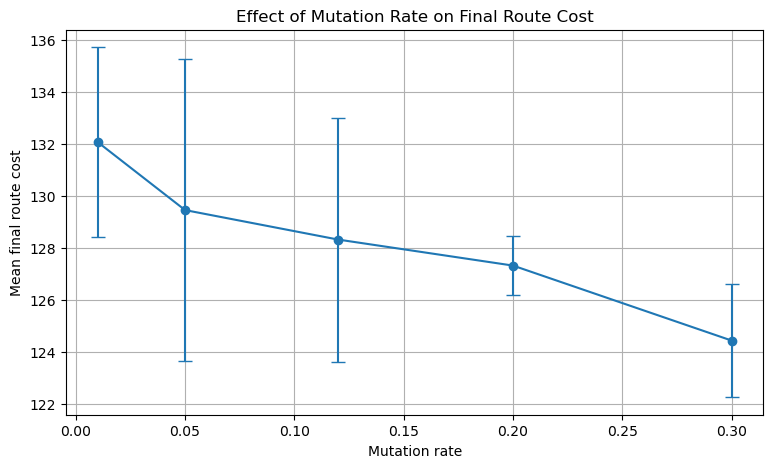

In [18]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    mutation_results["Mutation rate"],
    mutation_results["Mean final cost"],
    yerr=mutation_results["Standard deviation"],
    marker="o",
    capsize=5
)

plt.title("Effect of Mutation Rate on Final Route Cost")
plt.xlabel("Mutation rate")
plt.ylabel("Mean final route cost")
plt.grid(True)
plt.show()

### Mutation Rate Results

The mutation-rate experiment shows how much random variation should be introduced into the population. Very low mutation rates may limit exploration because the algorithm does not generate enough new route variations. Very high mutation rates can also be harmful because they disrupt good route structures too often.

A moderate mutation rate is expected to perform best because it balances exploration of new routes with preservation of strong candidate solutions.

In [19]:
def population_size_experiment(
    population_sizes=[30, 50, 100, 200],
    repeats=5,
    mutation_rate=0.12,
    generations=150
):

    # test several population sizes

    # larger populations explore more routes per generation (but require more computation)
    

    results = []

    for pop_size in population_sizes:
        final_costs = []

        for repeat in range(repeats):
            seed = 2000 + repeat

            best_individual, best_cost, history = run_ga_with_settings(
                pop_size=pop_size,
                generations=generations,
                mutation_rate=mutation_rate,
                seed=seed
            )

            final_costs.append(best_cost)

        results.append(
            {
                "Population size": pop_size,
                "Mean final cost": np.mean(final_costs),
                "Best final cost": np.min(final_costs),
                "Worst final cost": np.max(final_costs),
                "Standard deviation": np.std(final_costs)
            }
        )

    return pd.DataFrame(results)


population_results = population_size_experiment()
population_results


,Population size,Mean final cost,Best final cost,Worst final cost,Standard deviation
0,30,131.733390,122.82685,146.348383,7.836622
1,50,130.089626,128.32201,132.581753,1.613091
2,100,131.121390,128.32201,134.147041,2.614842
3,200,124.867929,122.82685,130.516162,2.987513


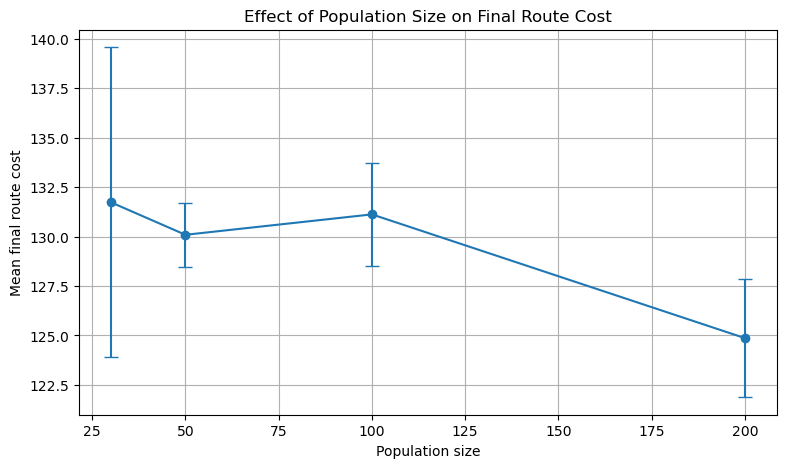

In [20]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    population_results["Population size"],
    population_results["Mean final cost"],
    yerr=population_results["Standard deviation"],
    marker="o",
    capsize=5
)

plt.title("Effect of Population Size on Final Route Cost")
plt.xlabel("Population size")
plt.ylabel("Mean final route cost")
plt.grid(True)
plt.show()

### Population Size Results

The population-size experiment evaluates how many candidate routes are maintained in each generation. Lower final route cost indicates better performance.

In general, population size can affect the genetic algorithm’s ability to explore the search space. Smaller populations are faster to compute, but they may have less route diversity and can become trapped in weaker solutions. Larger populations usually provide more diversity, which can help the algorithm explore more possible routes, but they also require more computation time.

This experiment demonstrates that population size is an important parameter because it can influence both optimization performance and computational cost.

## 12. Parameter Experiment Discussion

The parameter experiments show how genetic algorithm performance changes under different settings. Mutation rate controls how much random variation is introduced into the population. Population size controls how many candidate routes are evaluated in each generation.

If mutation is too low, the algorithm may not explore enough of the search space. If mutation is too high, strong route structures may be disrupted too often. Similarly, larger populations can improve exploration, but they require more computation.

These experiments demonstrate that genetic algorithm performance depends on parameter choices, not only on the fitness function.

## 13. Limitations

This project demonstrates the structure of climate-aware aircraft route optimization, but it has several limitations.

First, the airspace is simulated rather than based on real weather data. Real contrail prediction would require atmospheric data such as temperature, humidity, pressure, and altitude. Second, route distance is used as a simplified proxy for fuel use, but real aircraft fuel burn depends on aircraft type, weight, altitude, speed, climb profile, and weather conditions. Third, the model uses a two-dimensional grid and does not include altitude optimization. In reality, contrail avoidance may involve both horizontal rerouting and vertical flight-level changes.

The model also simplifies air traffic control constraints. Real aircraft routes must follow regulated airways, safety rules, separation requirements, and operational constraints.

Despite these limitations, the project successfully demonstrates how a genetic algorithm can optimize a route using multiple competing environmental objectives.

## 14. Conclusion

This project applied a genetic algorithm to the problem of climate-aware aircraft route optimization. Candidate routes were represented as sequences of waypoints, and each route was evaluated using a cost function based on distance, contrail-risk exposure, wind effects, smoothness, and restricted airspace penalties.

The genetic algorithm was able to evolve a route with lower total cost than the direct route baseline. The optimized route avoided high contrail-risk regions while keeping distance reasonable, demonstrating the tradeoff between fuel-related emissions and contrail-related climate impact.

The results show that evolutionary computing can be used to search complex route spaces where multiple objectives must be balanced. While the model is simplified, it provides a clear demonstration of how genetic algorithms can support environmental decision-making in flight path planning.